## Using numpy to cluster data

### Getting the data

In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np

### Get the data from files

Get a test and train data set and corresponding labels

In [3]:
def get_data():
    data_set_1_file = "data/cluster_data_set_2d.csv"
    data_labels_1_file = "data/cluster_data_set_2d_labels.csv"
    test_data_set_1_file = "data/cluster_test_data_set_2d.csv"
    test_data_labels_1_file = "data/cluster_test_data_set_2d_labels.csv"
    data_set_1 = np.loadtxt(data_set_1_file, delimiter=',', skiprows=1)
    data_labels_1 = np.loadtxt(data_labels_1_file, delimiter=',', skiprows=1, )
    test_data_set_1 = np.loadtxt(test_data_set_1_file, delimiter=',', skiprows=1)
    test_data_labels_1 = np.loadtxt(test_data_labels_1_file, delimiter=',', skiprows=1)
    return data_set_1,data_labels_1, test_data_set_1, test_data_labels_1

In [4]:
data_set_1,data_labels_1, test_data_set_1, test_data_labels_1=get_data()

In [5]:
from numpy_clustering_functions import leader_clustering

### Leader clustering

Create a function to do leader clustering for a number of threshold distances.

In [6]:
def perform_leader_clustering(data_set, cluster_results):
    # Perform leader clustering
    try:
        for threshold in np.array([0.8, 1.4, 2.0, 3.0, 4.0]):
            print(f"Clustering with threshold {threshold}")
            c1, l1 = leader_clustering(data_set, threshold)
            print(f"Clustering with threshold {threshold} completed")
            print(f"Number of clusters: {len(np.unique(l1))}")
            r = {'type': 'leader', 'parameter': threshold,'clusters': c1.copy(), 'labels': l1.copy()}
            cluster_results.append(r)
        return cluster_results
    except Exception as e:
        print("Unable to perform leader clustering", e)

In [7]:
cluster_results=[]
cluster_results=perform_leader_clustering(data_set_1, cluster_results)

Clustering with threshold 0.8
Clustering with threshold 0.8 completed
Number of clusters: 22
Clustering with threshold 1.4
Clustering with threshold 1.4 completed
Number of clusters: 11
Clustering with threshold 2.0
Clustering with threshold 2.0 completed
Number of clusters: 6
Clustering with threshold 3.0
Clustering with threshold 3.0 completed
Number of clusters: 3
Clustering with threshold 4.0
Clustering with threshold 4.0 completed
Number of clusters: 2


In [8]:
from numpy_clustering_functions import kmeans_clustering

### Create a function to perform kmeans clustering

Create a function to perform kmeans clustering using a number of cluster centers

In [9]:
def perform_k_means_clustering(data_set_1, cluster_results):
    # perform k-means clustering
    try:
        for n_clusters in np.array([2, 3, 4, 5, 6]):
            print(f"Clustering with {n_clusters} clusters")
            c1, l1 = kmeans_clustering(data_set_1, n_clusters)
            print(f"Clustering with {n_clusters} clusters completed")
            print(f"Number of clusters: {len(np.unique(l1))}")
            r = {'type': 'k-means', 'parameter': n_clusters,'num_of_clusters':n_clusters, 'clusters': c1.copy(), 'labels': l1.copy()}
            cluster_results.append(r)
        return cluster_results
    except Exception as e:
        print("Unable to perform k-means clustering", e)

In [10]:
cluster_results=perform_k_means_clustering(data_set_1, cluster_results)

Clustering with 2 clusters
Clustering with 2 clusters completed
Number of clusters: 2
Clustering with 3 clusters
Clustering with 3 clusters completed
Number of clusters: 3
Clustering with 4 clusters
Clustering with 4 clusters completed
Number of clusters: 4
Clustering with 5 clusters
Clustering with 5 clusters completed
Number of clusters: 5
Clustering with 6 clusters
Clustering with 6 clusters completed
Number of clusters: 6


In [11]:
from numpy_clustering_functions import intra_cluster_distance, inter_cluster_distance

In [12]:
def check_performance(cluster_results):
    for c in cluster_results:
        c['intra'] = intra_cluster_distance(data_set_1, c['labels'], c['clusters'])
        c['inter'] = inter_cluster_distance(data_set_1, c['labels'], c['clusters'])
    performance_ready = True if len(cluster_results) == 10 else False
    for i,c in enumerate(cluster_results):
        if 'intra' not in c.keys() or 'inter' not in c.keys():
            print(f"The clustering result {c['type']}/{c['parameter']} does not contain the expected fields.")
            performance_ready = False
        else:
            print(f"id={i}: The clustering result {c['type']}/{c['parameter']} - intra = {c['intra']} - inter = {c['inter']}")

    if not performance_ready:
        print("Not all clustering results contain the expected fields. Please check the implementation.")


In [13]:
check_performance(cluster_results)

id=0: The clustering result leader/0.8 - intra = [0.40274737 0.39318375] - inter = 6.950679203184295
id=1: The clustering result leader/1.4 - intra = [0.69137754 0.70337268] - inter = 7.041770957244185
id=2: The clustering result leader/2.0 - intra = [1.00921588 0.79722517] - inter = 7.2805364223114974
id=3: The clustering result leader/3.0 - intra = [1.3301447 1.2934942] - inter = 9.265631632918506
id=4: The clustering result leader/4.0 - intra = [1.32041756 2.02263503] - inter = 13.653398925599891
id=5: The clustering result k-means/2 - intra = [0.85544595 1.59464061] - inter = 10.637643280592766
id=6: The clustering result k-means/3 - intra = [0.84380421 0.72423708] - inter = 8.038604726986604
id=7: The clustering result k-means/4 - intra = [0.76980752 0.69411753] - inter = 8.222477890137759
id=8: The clustering result k-means/5 - intra = [0.7383635  0.68610686] - inter = 7.278418285219791
id=9: The clustering result k-means/6 - intra = [0.54794164 0.69349443] - inter = 6.3958794877

In [14]:
from numpy_clustering_functions import intra_cluster_distance, inter_cluster_distance, assign_data_to_cluster

### Selecting clusters results from the complete set of clustering results

In [15]:
def select_cluster_from_cluster_results_by_id(id, cluster_results, test_data_set_1):
    selected_cluster = cluster_results[id]
    test_cluster_result = {
        'type': selected_cluster['type'],
        'parameter': selected_cluster['parameter'],
        'clusters': selected_cluster['clusters'].copy()
    }
    test_cluster_result['labels'] = assign_data_to_cluster(test_data_set_1, selected_cluster['clusters'])
    test_cluster_result['intra'] = intra_cluster_distance(test_data_set_1, test_cluster_result['labels'], selected_cluster['clusters'])
    test_cluster_result['inter'] = inter_cluster_distance(test_data_set_1, test_cluster_result['labels'], selected_cluster['clusters'])
    return test_cluster_result, selected_cluster


In [16]:
test_cluster_result, selected_cluster=select_cluster_from_cluster_results_by_id(6,cluster_results, test_data_set_1)
other_test_cluster_result, other_selected_cluster=select_cluster_from_cluster_results_by_id(7,cluster_results, test_data_set_1)

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [18]:
def get_mapping(array1, array2):
    mapping={}
    for el_ar1, el_ar2 in zip(array1,array2):
        mapping[el_ar1]=el_ar2
    return mapping

def apply_mapping(array, mapping):
    mapped_list=[]
    for ar_el in array:
        mapped_list.append(mapping[ar_el])
    return np.asarray(mapped_list)

def group(data, cluster_ids):
    data = np.concatenate((cluster_ids[:, np.newaxis], data), axis=1)
    data = data[data[:, 0].argsort()]
    clusters = np.array_split(data[:, :], np.unique(data[:, 0], return_index=True)[1][1:])
    return clusters

    

### The clusters visualized

In this part clusters are being visualized. In the left part of the plot I compared the kmeans clustering results, having 3 clusters, to the targeted clustering. In this case no differences are to be noticed. On the right I compared the target clustering to a kmeans clustering with 4 centers. In this case differences are noticeable.

In [ ]:
def visualize_cluster(selected_cluster,ax, data_set, data_labels):
    cluster_labels=selected_cluster['labels']
    colormap = np.array(['r', 'g', 'b','y'])
    marker_map= ['*', '+', 'd','x']

    cluster_labels_test=data_labels.astype(np.int32)
    if np.unique(cluster_labels).shape==np.unique(cluster_labels_test).shape:
        mapping=get_mapping(cluster_labels, cluster_labels_test)
        cluster_labels=apply_mapping(cluster_labels,mapping)

    predicted_clusters=group(data_set, cluster_labels)
    target_clusters=group(data_set, cluster_labels_test)

    for ar in target_clusters:
        ax.scatter(ar[:,1],ar[:,2], c=colormap[ar[:,0].astype(np.int32)], marker='o',s=45, alpha=0.75, label=f"target {int(ar[0,0])}")

    for ar in predicted_clusters:
        ax.scatter(ar[:,1],ar[:,2], c="black", marker=marker_map[int(ar[0,0])], alpha=1, label=f"predicted {int(ar[0,0])}")

    ax.scatter(selected_cluster['clusters'][:,0],selected_cluster['clusters'][:,1], marker='^',s=90, color='black',label='predicted cluster centers')
    ax.title.set_text(f"Clustering data set with {selected_cluster['type']}/{selected_cluster['parameter']}.")
    ax.legend()
    return ax

NameError: name 'ari_score' is not defined

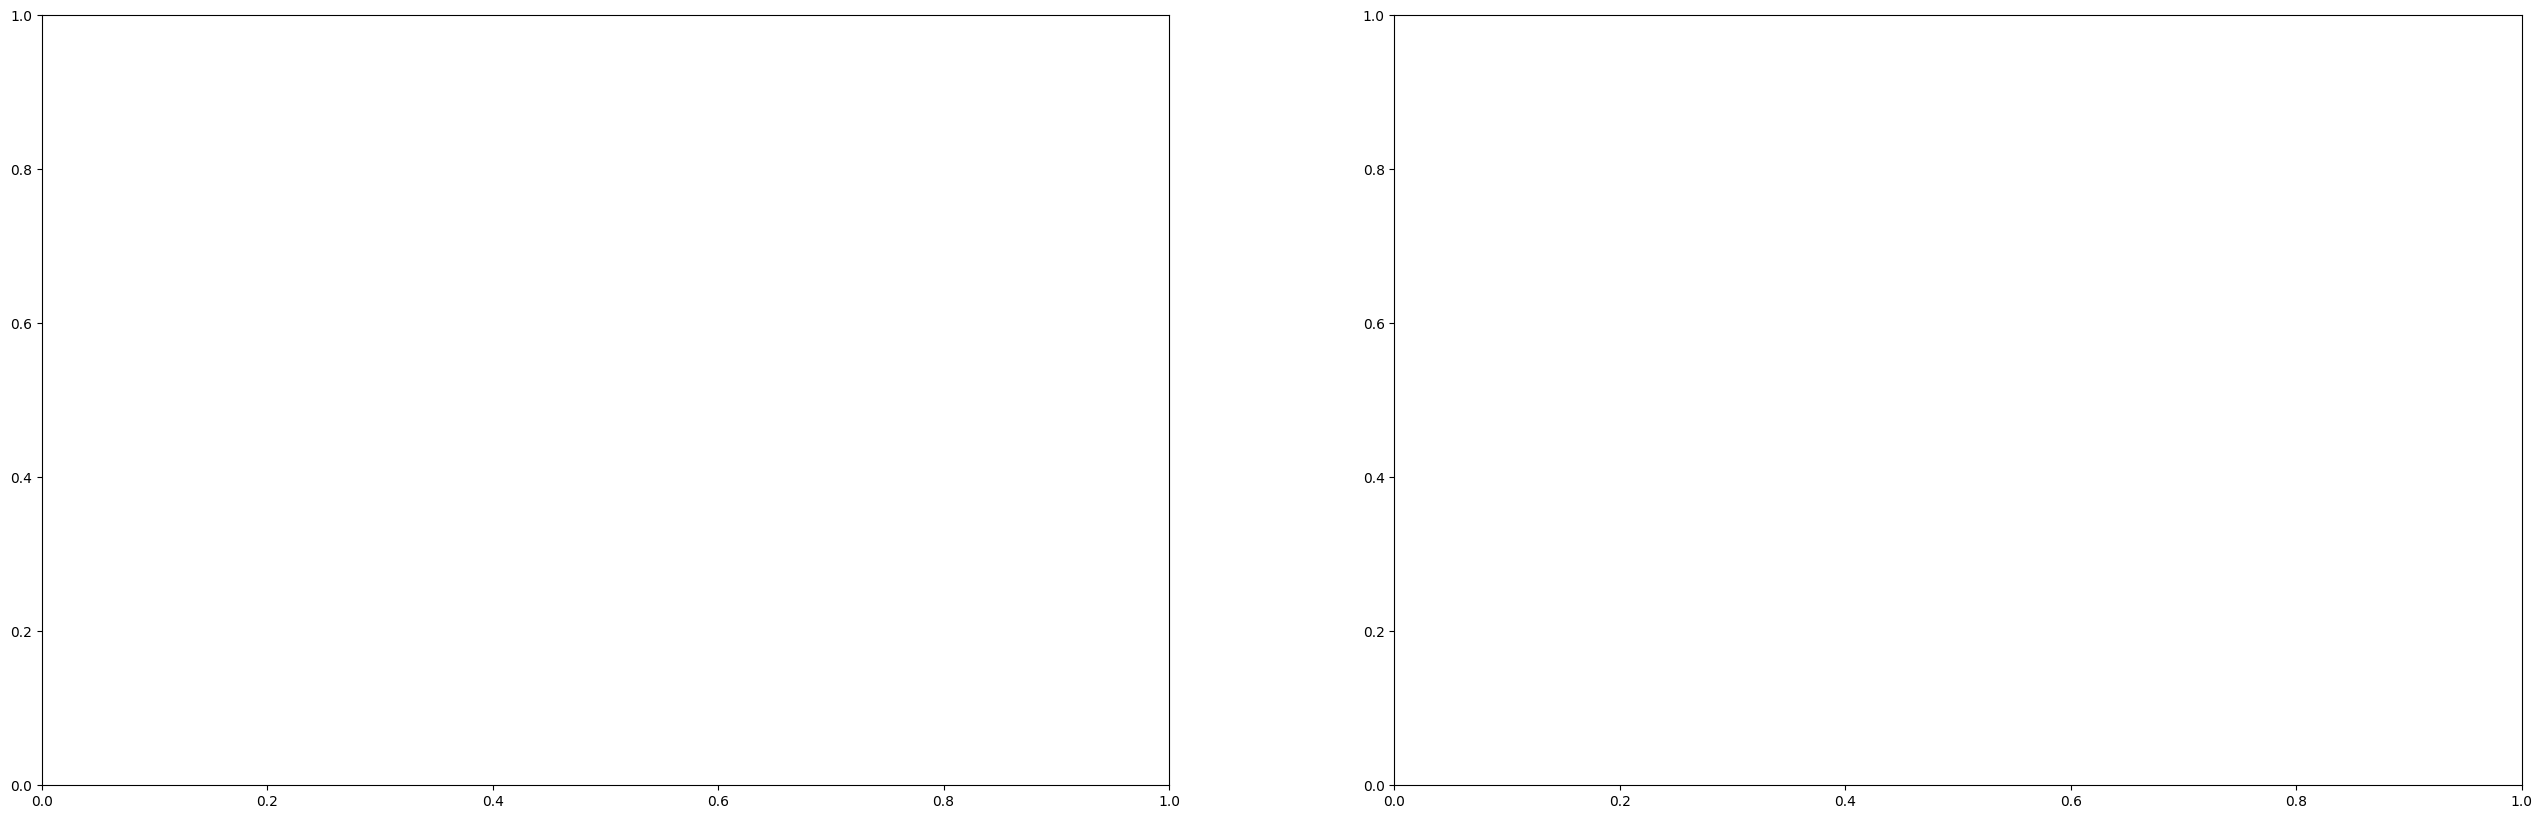

In [20]:
fig, ax=plt.subplots(1,2, figsize=[32,10])
ax[0]=visualize_cluster(selected_cluster,ax[0],data_set_1, data_labels_1)
ax[1]=visualize_cluster(other_selected_cluster,ax[1],data_set_1, data_labels_1)
fig.suptitle(f"Clustering data set compared.", fontsize=30)

#legend_without_duplicate_labels(fig)